In [237]:
# Import neccessary packages

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import gudhi
from gudhi import RipsComplex
from gudhi.representations import PersistenceImage
from sklearn.model_selection import train_test_split
import torch 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin





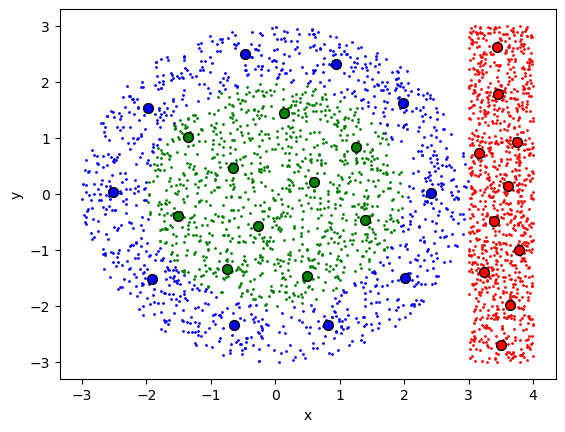

In [238]:
def gen_annulus_pts(r_inner, r_outer, num_points):
    rng = np.random.default_rng()
    theta = rng.uniform(0, 2 * np.pi, num_points)
    r_sq = rng.uniform(r_inner**2, r_outer**2, num_points)
    r = np.sqrt(r_sq)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

def gen_rect_pts(top,bottom, left, right, num_points):
    rng = np.random.default_rng()
    x = rng.uniform(left, right, num_points)
    y = rng.uniform(bottom, top, num_points)
    return np.column_stack((x, y))

def k_means_clustering(data, num_of_clusters):
    # 2. Initialize and fit K-Means
    k = 5  # Number of representative samples you want
    kmeans = KMeans(n_clusters=num_of_clusters, random_state=42).fit(data)

    # 3. Get the calculated cluster centers (centroids)
    centroids = kmeans.cluster_centers_

    # 4. Find the closest actual data point to each centroid
    # This ensures your sample consists of real points, not mathematical averages
    rep_id = pairwise_distances_argmin(centroids, data)
    clustering = data[rep_id]
    return clustering

annulus = gen_annulus_pts(2,3,1000)
cluster_1 = k_means_clustering(annulus, 10)
circle = gen_annulus_pts(0,2,1000)
cluster_2 = k_means_clustering(circle, 10)
rect = gen_rect_pts(3,-3,3,4, 1000)
cluster_3 = k_means_clustering(rect, 10)

clusters = np.stack((cluster_1,cluster_2, cluster_3))
X = np.vstack((annulus,circle,rect))
y = np.zeros((len(X)))
y[1000:2000] = 1
y[2000:3000] = 2

plt.scatter(annulus[:,0], annulus[:,1], s=1, color = "blue",marker ="o")
plt.scatter(circle[:,0], circle[:,1], s=1, color = "green",marker ="o")
plt.scatter(rect[:,0], rect[:,1], s=1, color = "red",marker ="o")
colors = ["blue","green","red"]
for i in range(3):
    plt.scatter(clusters[i,:,0], clusters[i,:,1], s=50, color = colors[i], marker ="o", edgecolors='black',linewidths=1)
    
plt.xlabel("x")
plt.ylabel("y")
plt.show()





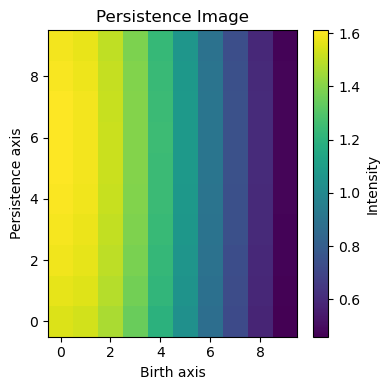

(2400, 3, 10, 10)
(300, 3, 10, 10)
(300, 3, 10, 10)
[2. 1. 0. ... 1. 2. 2.]


In [239]:
img_res = 10
num_of_classes = len(np.unique(y))

def gen_persistence_image(input, cluster):
    point_cloud = np.vstack((input,cluster))
    rips = RipsComplex(points = point_cloud)
    simplex_tree = rips.create_simplex_tree(max_dimension=2)
    diag = simplex_tree.persistence()
    diag_intervals = np.array([i[1] for i in diag if i[1][1] != np.inf])
    PI = PersistenceImage(resolution=[img_res, img_res]).fit_transform([diag_intervals])
    return PI

features = np.zeros((len(X),num_of_classes,img_res*img_res))

for i in range(len(X)):
    for j in range(num_of_classes):
        features[i][j] = gen_persistence_image(X[i],clusters[j])


X_train, X_test, train_targets, test_targets = train_test_split(
                                                features, 
                                                y, 
                                                test_size=0.2, 
                                                random_state=2)


X_validation, X_test, validation_targets, test_targets = train_test_split(
                                                    X_test, 
                                                    test_targets, 
                                                    test_size=0.5, 
                                                    random_state=2)



train_features = np.reshape(X_train, (len(X_train), 3, img_res, img_res))
validation_features = np.reshape(X_validation, (len(X_validation), 3, img_res, img_res))
test_features = np.reshape(X_test, (len(X_test), 3, img_res, img_res))


plt.figure(figsize=(4, 4))
plt.imshow(train_features[1][0], origin="lower", cmap="viridis", aspect="auto")
plt.colorbar(label="Intensity")
plt.title("Persistence Image")
plt.xlabel("Birth axis")
plt.ylabel("Persistence axis")
plt.tight_layout()
plt.show()

print(train_features.shape)
print(validation_features.shape)
print(test_features.shape)
print(train_targets)


In [240]:
import torch.nn as nn

class simpleCNN(nn.Module):
    def __init__(self, num_channels, num_of_classes, image_res, hidden_layer_size):

        super(simpleCNN, self).__init__()
        # We seperate our layers into blocks 

        #The convolutional block consists of two convolutional layers,
        self.conv_layers = nn.Sequential(
            nn.Conv2d(num_channels, 8, kernel_size=3, padding=1),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
        )

        # The fully connected block 
        # three layers with linear activation and dropout for regularization
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * image_res * image_res, hidden_layer_size),
            nn.Dropout(0.3),
            nn.Linear(hidden_layer_size, hidden_layer_size),
            nn.Dropout(0.3),
            nn.Linear(hidden_layer_size, num_of_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [241]:
model = simpleCNN(
    num_channels = 3, 
    num_of_classes = 3, 
    image_res = img_res,
    hidden_layer_size = 5
)

learning_rate = 0.0001
epochs  = 5
batchsize = 1

# We will use gradient descent for our optimizer and Mean Squared Error Loss function
loss_func = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

train_loss_list = []
validation_accuracy_list = np.zeros((epochs,))

In [242]:
import tqdm # Use "for epoch in tqdm.trange(epochs):" to see the progress bar

# Convert the training, validation, testing dataset (NumPy arrays) into torch tensors
# Split your training features/targets into mini-batches if using mini-batch gradient

train_inputs = torch.from_numpy(train_features).float()
train_targets = torch.from_numpy(train_targets).long()

validation_inputs = torch.from_numpy(validation_features).float()
validation_targets = torch.from_numpy(validation_targets).long()

testing_inputs = torch.from_numpy(test_features).float()
testing_targets = torch.from_numpy(test_targets).long()

# Use torch.split() function to split the training inputs/targets into mini-batches
train_batches_features = torch.split(train_inputs, batchsize)
train_batches_targets = torch.split(train_targets, batchsize)

# length of train_batches_features = total number of mini-batches in the training set
batch_split_num = len(train_batches_features)

# Training Loop ---------------------------------------------------------------------------------------

for epoch in range(epochs):
    model.train() # Set the model to training mode
    
    for k in range(batch_split_num):
    
        optimizer.zero_grad()
            
        train_batch_outputs = model(train_batches_features[k])

        loss = loss_func(train_batch_outputs, train_batches_targets[k])

        train_loss_list.append(loss.item())

        loss.backward()

        optimizer.step()

    # Compute Validation Accuracy ----------------------------------------------------------------------

    with torch.no_grad():
        model.eval() # Set the model to evaluation mode to turn off dropout layers

        validation_outputs = model(validation_inputs)

        correct = (torch.argmax(validation_outputs, dim=1) == 
                   validation_targets).type(torch.FloatTensor)
        
        print("Epoch: "+ str(epoch), 
              "Validation Accuracy: " + str(np.round(correct.mean().numpy() * 100, 2)) + '%', flush=True)

        validation_accuracy_list[epoch] = correct.mean()


Epoch: 0 Validation Accuracy: 87.33%
Epoch: 1 Validation Accuracy: 96.0%
Epoch: 2 Validation Accuracy: 96.67%
Epoch: 3 Validation Accuracy: 97.0%
Epoch: 4 Validation Accuracy: 97.67%


Text(0, 0.5, 'validation accuracy')

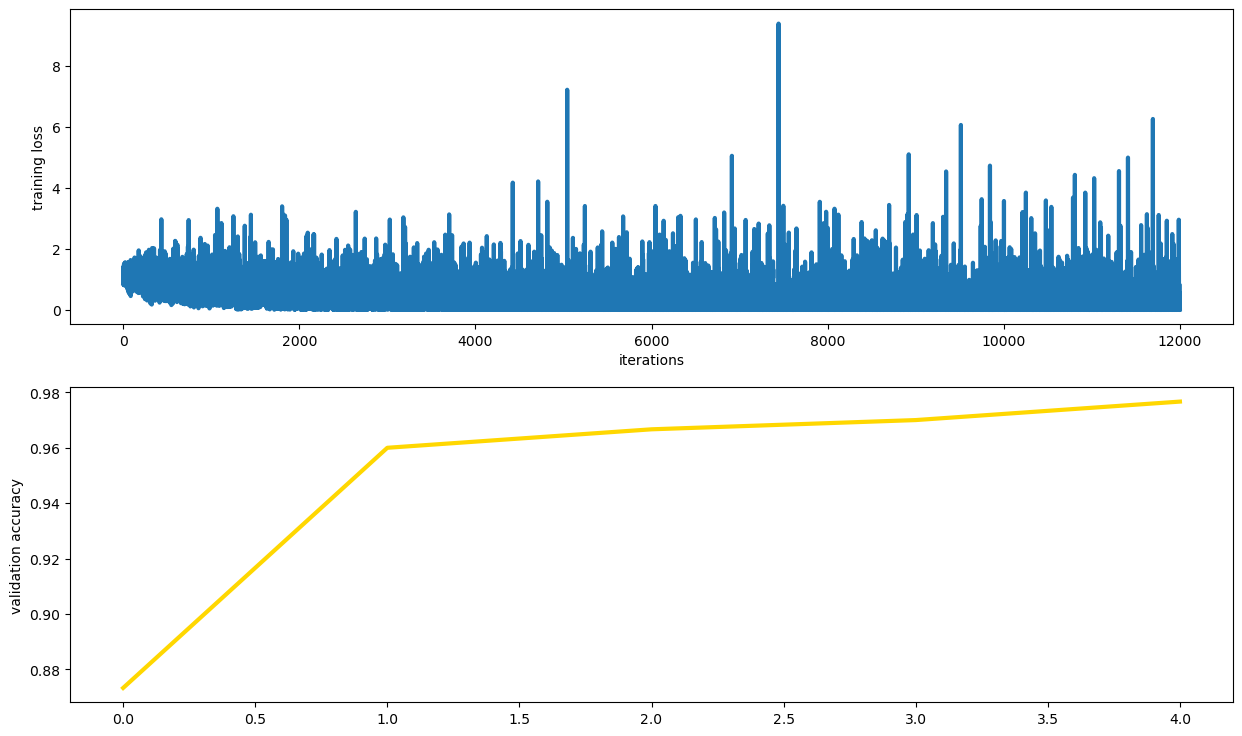

In [243]:


plt.figure(figsize = (15, 9))

plt.subplot(2, 1, 1)
plt.plot(train_loss_list, linewidth = 3)
plt.ylabel("training loss")
plt.xlabel("iterations")


plt.subplot(2, 1, 2)
plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
plt.ylabel("validation accuracy")


In [244]:
# Compute the testing accuracy 

with torch.no_grad():
    model.eval() # Set the model to evaluation mode to turn off dropout layers
    
    y_pred_test = model(testing_inputs)
     
    correct = (torch.argmax(y_pred_test, dim=1) == testing_targets).type(torch.FloatTensor)
    
    print("Testing Accuracy: " + str(correct.mean().numpy()))

Testing Accuracy: 0.93333334
